# JET Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the JET ensemble, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the BESS-JPL model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed, sensitivity_magnitude_barchart
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Configuration Options

Set configuration options for the notebook, including whether to save plots to files.

In [2]:
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    "ST_C": 0.0,
    "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0,
}

input_max = {
    "ST_C": 50.0,
    "NDVI": 1,
    "albedo": 1,
}

## Define Processing Function for Model Table

This cell defines the forward process for analysis as the BESS-JPL model.

In [3]:
forward_process = process_JET_table
model_name = "JET"

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [4]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out surface temperatures greater than 50 Celsius and NDVI values less than 0.05. The resulting DataFrame is displayed for inspection.

In [5]:
input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,2.58,0.4060,0.32,0.14
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,8.48,0.4017,0.29,0.12


## Plot Change in Surface Temperature vs Net Radiation

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in BESS-JPL net radiation due to input perturbations. The plot is saved as JPEG and SVG files.

In [16]:
def monte_carlo_scatter_analysis(
    input_df,
    input_variable,
    output_variable,
    forward_process,
    normalization_function: Callable = divide_absolute_by_unperturbed
):
    perturbed_output = perturbed_run(
        input_df=input_df, 
        input_variable=input_variable, 
        output_variable=output_variable, 
        forward_process=process_JET_table,
        normalization_function=normalization_function
    )

    Rn_results

    sc = plt.scatter(
        x=perturbed_output.input_perturbation, 
        y=perturbed_output.output_perturbation, 
        c=perturbed_output.input_unperturbed, 
        color=None,
        cmap="jet",
        s=3,
        alpha=0.5, 
        zorder=5
    )

    plt.grid(True, zorder=0)
    plt.xlabel(f"Change in input {input_variable}")
    plt.ylabel(f"Change in  output {output_variable}")
    plt.title(f"Comparison of change in {input_variable} to {output_variable}", pad=20)
    plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")

    plt.show()

[2026-08-11 13:23:04 INFO] Starting Monte Carlo perturbed run
[2026-08-11 13:23:04 INFO] calculating standard deviation of input variable: ST_C
[2026-08-11 13:23:04 INFO] input variable ST_C standard deviation: 10.766741663428046
[2026-08-11 13:23:04 INFO] starting forward process
[2026-08-11 13:23:04 INFO] starting JET table processing
[2026-08-11 13:23:04 INFO] started extracting geometry from JET input table
[2026-08-11 13:23:04 INFO] completed extracting geometry from JET input table (0.005 seconds)
[2026-08-11 13:23:04 INFO] started extracting time from JET input table
[2026-08-11 13:23:04 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-11 13:23:04 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[2026-08-11 13:23:04 INFO] completed processing FLiES-ANN in 0.18 seconds
[2026-08-11 13:23:04 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable NIR_albedo 

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:23:04 INFO] variable canopy_temperature_C min: 3.730 mean: 30.458 max: 49.990 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable soil_temperature_C min: 3.730 mean: 30.458 max: 49.990 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] using given FLiES output as BESS parameters
[2026-08-11 13:23:04 INFO] variable Ps_Pa min: 66823.360 mean: 88555.415 max: 101241.460 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable VPD_Pa min: 189.019 mean: 1796.608 max: 3845.601 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable RH min: 0.273 mean: 0.387 max: 0.874 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable desTa min: 49.999 mean: 173.694 max: 318.308 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable ddesTa min: 3.165 mean: 9.054 max: 15.194 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable gamma min: 44.648 mean: 58.961 max: 68.139 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable Cp min: 1006.679 mean: 1012.269 max: 1019.788 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

[2026-08-11 13:23:04 INFO] * 2900.0: 21
[2026-08-11 13:23:04 INFO] * 3000.0: 23
[2026-08-11 13:23:04 INFO] * 3500.0: 52
[2026-08-11 13:23:04 INFO] * 3600.0: 5
[2026-08-11 13:23:04 INFO] * 4200.0: 126
[2026-08-11 13:23:04 INFO] * 4400.0: 37
[2026-08-11 13:23:04 INFO] * 4500.0: 6
[2026-08-11 13:23:04 INFO] variable mVPD min: 0.000 mean: 0.646 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable gs1 min: 0.000 mean: 0.004 max: 0.009 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable Gcu min: 0.000 mean: 0.000 max: 0.000 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable Cc min: 0.001 mean: 0.003 max: 0.020 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable rs min: 51.091 mean: 739.841 max: 2000.000 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable rh min: 51.091 mean: 739.841 max: 2000.000 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable rr min: 173.391 mean: 241.785 max: 327.865 nan: 0.00% (nan)
[2026-08-11 13:23:04 INFO] variable ra min: 11.659 mean: 32.332 max: 

...

[2026-08-11 13:23:09 INFO] variable Ms min: 0.000 mean: 0.166 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:09 INFO] running STIC iteration 1 / 3
[2026-08-11 13:23:09 INFO] using variable Priestley-Taylor alpha with mean: 1.592
[2026-08-11 13:23:09 INFO] completed STIC iteration 1 / 3 with max LE change: 1808.241 (0.006612583005335182 seconds)
[2026-08-11 13:23:09 INFO] variable SM_1 min: 0.000 mean: 0.109 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:09 INFO] variable G_1 min: 0.000 mean: 66.350 max: 200.948 nan: 0.00% (nan)
[2026-08-11 13:23:09 INFO] variable LE_1 min: 0.000 mean: 190.506 max: 968.711 nan: 0.00% (nan)
[2026-08-11 13:23:09 INFO] running STIC iteration 2 / 3
[2026-08-11 13:23:09 INFO] using variable Priestley-Taylor alpha with mean: 3.909
[2026-08-11 13:23:09 INFO] completed STIC iteration 2 / 3 with max LE change: 106.598 (0.018984374997671694 seconds)
[2026-08-11 13:23:09 INFO] variable SM_2 min: 0.000 mean: 0.111 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:09 INFO

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:23:10 INFO] completed daylight ET upscaling (elapsed: 0.69 seconds)
[2026-08-11 13:23:10 INFO] PT-JPL-SM model run complete (elapsed: 0.73 seconds)
[2026-08-11 13:23:10 INFO] completed processing PT-JPL-SM in 0.73 seconds
[2026-08-11 13:23:10 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 190.994 max: 788.342 nan: 0.00% (nan)
[2026-08-11 13:23:10 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.608 max: 10.484 nan: 0.00% (nan)
[2026-08-11 13:23:10 INFO] variable G_PTJPLSM min: 0.000 mean: 66.350 max: 200.948 nan: 0.00% (nan)
[2026-08-11 13:23:10 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.418 max: 0.964 nan: 0.00% (nan)
[2026-08-11 13:23:10 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 127.705 max: 605.468 nan: 0.00% (nan)
[2026-08-11 13:23:10 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.097 mean: 0.747 max: 0.978 nan: 0.16% (nan)
[2026-08-11 13:23:10 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 55.843 max: 544.855 nan: 0.00% (nan)
[2026-08-11

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:23:11 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-11 13:23:11 INFO] completed processing PM-JPL in 0.81 seconds
[2026-08-11 13:23:11 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 94.098 max: 524.486 nan: 0.00% (nan)
[2026-08-11 13:23:11 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.320 max: 6.911 nan: 0.00% (nan)
[2026-08-11 13:23:11 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 66.350 max: 200.948 nan: 0.00% (nan)
[2026-08-11 13:23:11 INFO] variable ET_daylight_kg min: 0.000 mean: 1.734 max: 7.921 nan: 0.00% (nan)
[2026-08-11 13:23:11 INFO] JET table processing complete (6.326 seconds)
[2026-08-11 13:23:11 INFO] completed forward process for perturbed input
[2026-08-11 13:23:11 INFO] normalizing output perturbations
[2026-08-11 13:23:11 INFO] Monte Carlo run complete


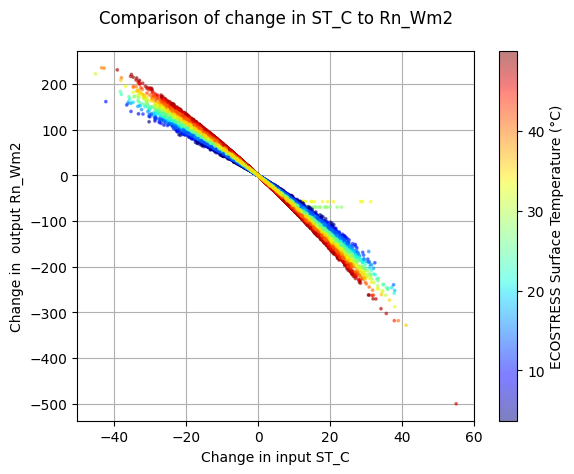

In [17]:
input_variable = "ST_C"
output_variable = "Rn_Wm2"

monte_carlo_scatter_analysis(
    input_df=input_df,
    input_variable=input_variable,
    output_variable=output_variable,
    forward_process=forward_process,
    normalization_function=normalization_function
)

## Plot Change in Surface Temperature vs Evapotranspiration

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in evapotranspiration due to input perturbations. The plot is saved as JPEG and SVG files.

[2026-08-11 13:23:41 INFO] Starting Monte Carlo perturbed run
[2026-08-11 13:23:41 INFO] calculating standard deviation of input variable: ST_C
[2026-08-11 13:23:41 INFO] input variable ST_C standard deviation: 10.766741663428046
[2026-08-11 13:23:41 INFO] starting forward process
[2026-08-11 13:23:41 INFO] starting JET table processing
[2026-08-11 13:23:41 INFO] started extracting geometry from JET input table
[2026-08-11 13:23:41 INFO] completed extracting geometry from JET input table (0.005 seconds)
[2026-08-11 13:23:41 INFO] started extracting time from JET input table
[2026-08-11 13:23:41 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-11 13:23:41 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[2026-08-11 13:23:41 INFO] completed processing FLiES-ANN in 0.17 seconds
[2026-08-11 13:23:41 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable NIR_albedo 

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:23:41 INFO] variable Ps_Pa min: 66823.360 mean: 88555.415 max: 101241.460 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable VPD_Pa min: 189.019 mean: 1796.608 max: 3845.601 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable RH min: 0.273 mean: 0.387 max: 0.874 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable desTa min: 49.999 mean: 173.694 max: 318.308 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable ddesTa min: 3.165 mean: 9.054 max: 15.194 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable gamma min: 44.648 mean: 58.961 max: 68.139 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable Cp min: 1006.679 mean: 1012.269 max: 1019.788 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable rhoa min: 0.776 mean: 1.045 max: 1.231 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable epsa min: 0.679 mean: 0.765 max: 0.966 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable R min: 14.018 mean: 108.103 max: 1000.000 nan: 0.00% (nan)
[2026-08-11 13:23:41 INFO] variable

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

[2026-08-11 13:23:42 INFO] starting input perturbation generation
[2026-08-11 13:23:42 INFO] input perturbation generation completed
[2026-08-11 13:23:42 INFO] generating control group
[2026-08-11 13:23:42 INFO] normalizing input perturbations
[2026-08-11 13:23:42 INFO] applying perturbations
[2026-08-11 13:23:42 INFO] starting forward process for perturbed input
[2026-08-11 13:23:42 INFO] starting JET table processing
[2026-08-11 13:23:42 INFO] started extracting geometry from JET input table
[2026-08-11 13:23:42 INFO] completed extracting geometry from JET input table (0.227 seconds)
[2026-08-11 13:23:42 INFO] started extracting time from JET input table
[2026-08-11 13:23:42 INFO] completed extracting time from JET input table (0.011 seconds)
[2026-08-11 13:23:42 INFO] running Forest Light Environmental Simulator


...

[2026-08-11 13:23:46 INFO] variable Ms min: 0.000 mean: 0.166 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:46 INFO] running STIC iteration 1 / 3
[2026-08-11 13:23:46 INFO] using variable Priestley-Taylor alpha with mean: 1.559
[2026-08-11 13:23:46 INFO] completed STIC iteration 1 / 3 with max LE change: 1750.047 (0.004508208017796278 seconds)
[2026-08-11 13:23:46 INFO] variable SM_1 min: 0.000 mean: 0.109 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:46 INFO] variable G_1 min: 0.000 mean: 66.374 max: 200.821 nan: 0.00% (nan)
[2026-08-11 13:23:46 INFO] variable LE_1 min: 0.000 mean: 191.149 max: 938.877 nan: 0.00% (nan)
[2026-08-11 13:23:46 INFO] running STIC iteration 2 / 3
[2026-08-11 13:23:46 INFO] using variable Priestley-Taylor alpha with mean: 3.638
[2026-08-11 13:23:46 INFO] completed STIC iteration 2 / 3 with max LE change: 105.934 (0.016204875020775944 seconds)
[2026-08-11 13:23:46 INFO] variable SM_2 min: 0.000 mean: 0.111 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:23:46 INFO

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:23:47 INFO] completed daylight ET upscaling (elapsed: 0.69 seconds)
[2026-08-11 13:23:47 INFO] PT-JPL-SM model run complete (elapsed: 0.77 seconds)
[2026-08-11 13:23:47 INFO] completed processing PT-JPL-SM in 0.77 seconds
[2026-08-11 13:23:47 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 190.893 max: 851.596 nan: 0.00% (nan)
[2026-08-11 13:23:47 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.606 max: 9.996 nan: 0.00% (nan)
[2026-08-11 13:23:47 INFO] variable G_PTJPLSM min: 0.000 mean: 66.374 max: 200.821 nan: 0.00% (nan)
[2026-08-11 13:23:47 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.418 max: 0.964 nan: 0.00% (nan)
[2026-08-11 13:23:47 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 127.735 max: 617.270 nan: 0.00% (nan)
[2026-08-11 13:23:47 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.097 mean: 0.747 max: 0.978 nan: 0.17% (nan)
[2026-08-11 13:23:47 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 55.700 max: 506.986 nan: 0.00% (nan)
[2026-08-11 

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:23:48 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-11 13:23:48 INFO] completed processing PM-JPL in 0.79 seconds
[2026-08-11 13:23:48 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 94.112 max: 540.927 nan: 0.00% (nan)
[2026-08-11 13:23:48 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.319 max: 6.911 nan: 0.00% (nan)
[2026-08-11 13:23:48 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 66.374 max: 200.821 nan: 0.00% (nan)
[2026-08-11 13:23:48 INFO] variable ET_daylight_kg min: 0.000 mean: 1.733 max: 7.943 nan: 0.00% (nan)
[2026-08-11 13:23:48 INFO] JET table processing complete (6.436 seconds)
[2026-08-11 13:23:48 INFO] completed forward process for perturbed input
[2026-08-11 13:23:48 INFO] normalizing output perturbations
[2026-08-11 13:23:48 INFO] Monte Carlo run complete


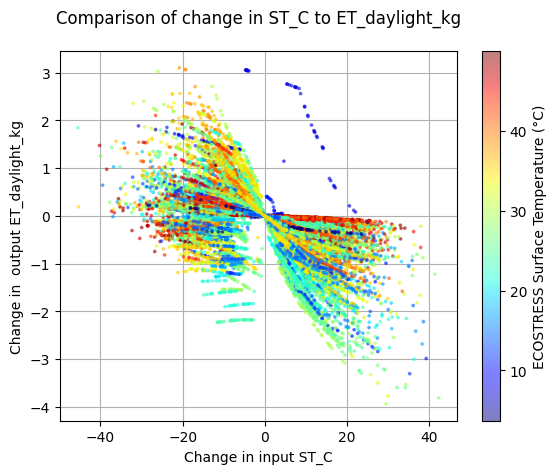

In [18]:
input_variable = "ST_C"
output_variable = "ET_daylight_kg"

# ET_results = perturbed_run(
#     input_df=input_df, 
#     input_variable=input_variable, 
#     output_variable=output_variable, 
#     forward_process=forward_process,
#     normalization_function=normalization_function
# )

# ET_results = ET_results.dropna()

# ET_results

# sc = plt.scatter(
#     x=ET_results.input_perturbation, 
#     y=ET_results.output_perturbation, 
#     c=ET_results.input_unperturbed, 
#     color=None,
#     cmap="jet",
#     s=3,
#     alpha=0.5, 
#     zorder=5
# )

# plt.grid(True, zorder=0)
# plt.xlabel("Change in Surface Temperature (°C)")
# plt.ylabel(f"Change in {model_name} Evapotranspiration (mm/day)")
# plt.title(f"Comparison of Change\nin Surface Temperature\nto {model_name} Evapotranspiration")
# plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")

# plt.show()

monte_carlo_scatter_analysis(
    input_df=input_df,
    input_variable=input_variable,
    output_variable=output_variable,
    forward_process=forward_process,
    normalization_function=normalization_function
)

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [28]:
def monte_carlo_barchart_analysis(
    input_df,
    input_variables,
    output_variable,
    forward_process,
    normalization_function: Callable = divide_absolute_by_unperturbed
):
    perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
        input_df=input_df,
        input_variables=input_variables,
        output_variables=output_variables,
        forward_process=process_JET_table,
        normalization_function=normalization_function,
        use_joint_run=True,  # Explicitly enable joint run mode
        input_min=input_min,
        input_max=input_max
    )
    
    sensitivity_magnitude_barchart(
        model_name=model_name,
        output_variable=output_variable,
        df=sensitivity_metrics_df
    )

[2026-08-11 13:39:40 INFO] starting JET table processing
[2026-08-11 13:39:40 INFO] started extracting geometry from JET input table
[2026-08-11 13:39:40 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-11 13:39:40 INFO] started extracting time from JET input table
[2026-08-11 13:39:40 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-11 13:39:40 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[2026-08-11 13:39:40 INFO] completed processing FLiES-ANN in 0.17 seconds
[2026-08-11 13:39:40 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-11 13:3

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:39:40 INFO] variable R min: 14.018 mean: 108.103 max: 1000.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable Rc min: 14.018 mean: 108.103 max: 1000.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable Rs min: 7.009 mean: 54.052 max: 500.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable SFd min: 0.020 mean: 0.051 max: 0.077 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable SFd2 min: 0.172 mean: 0.334 max: 0.983 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable DL min: 8.245 mean: 11.401 max: 14.086 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable Ra min: 416.618 mean: 888.643 max: 1240.699 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable fStress min: 0.012 mean: 0.239 max: 0.975 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable VCmax_C3_sunlit_μmolm2s1 min: 2.423 mean: 27.344 max: 141.877 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable VCmax_C4_sunlit_μmolm2s1 min: 1.561 mean: 22.475 max: 141.877 nan: 0.00% (nan)
[2026-08-11 13:39:4

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

[2026-08-11 13:39:40 INFO] * 3600.0: 5
[2026-08-11 13:39:40 INFO] * 4200.0: 126
[2026-08-11 13:39:40 INFO] * 4400.0: 37
[2026-08-11 13:39:40 INFO] * 4500.0: 6
[2026-08-11 13:39:40 INFO] variable mVPD min: 0.000 mean: 0.646 max: 1.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable gs1 min: 0.000 mean: 0.004 max: 0.009 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable Gcu min: 0.000 mean: 0.000 max: 0.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable Cc min: 0.001 mean: 0.003 max: 0.020 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable rs min: 51.091 mean: 739.841 max: 2000.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable rh min: 51.091 mean: 739.841 max: 2000.000 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable rr min: 173.391 mean: 241.785 max: 327.865 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable ra min: 11.659 mean: 32.332 max: 71.565 nan: 0.00% (nan)
[2026-08-11 13:39:40 INFO] variable LE_canopy_Wm2 min: 3.944 mean: 93.203 max: 477.694 nan: 0.00

...

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:40:01 INFO] completed daylight ET upscaling (elapsed: 2.71 seconds)
[2026-08-11 13:40:01 INFO] PT-JPL-SM model run complete (elapsed: 2.80 seconds)
[2026-08-11 13:40:01 INFO] completed processing PT-JPL-SM in 2.80 seconds
[2026-08-11 13:40:01 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 191.677 max: 891.595 nan: 0.00% (nan)
[2026-08-11 13:40:01 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.627 max: 12.065 nan: 0.00% (nan)
[2026-08-11 13:40:01 INFO] variable G_PTJPLSM min: 0.000 mean: 68.880 max: 211.602 nan: 0.00% (nan)
[2026-08-11 13:40:01 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.416 max: 1.124 nan: 0.00% (nan)
[2026-08-11 13:40:01 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 127.845 max: 693.595 nan: 0.00% (nan)
[2026-08-11 13:40:01 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.000 mean: 0.740 max: 1.000 nan: 0.06% (nan)
[2026-08-11 13:40:01 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 55.918 max: 526.657 nan: 0.00% (nan)
[2026-08-11

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:40:04 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-11 13:40:04 INFO] completed processing PM-JPL in 2.94 seconds
[2026-08-11 13:40:04 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 92.892 max: 515.812 nan: 0.00% (nan)
[2026-08-11 13:40:04 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.305 max: 9.166 nan: 0.00% (nan)
[2026-08-11 13:40:04 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 68.880 max: 211.602 nan: 0.00% (nan)
[2026-08-11 13:40:04 INFO] variable ET_daylight_kg min: 0.000 mean: 1.810 max: 9.235 nan: 0.00% (nan)
[2026-08-11 13:40:04 INFO] JET table processing complete (23.622 seconds)


ValueError: Axis limits cannot be NaN or Inf

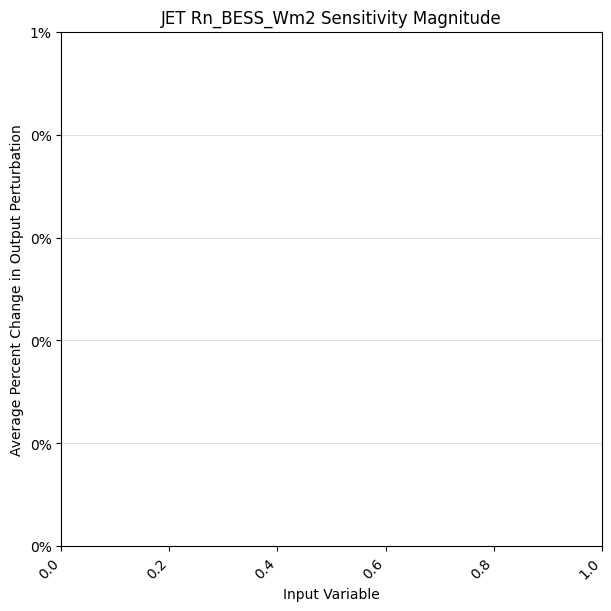

In [29]:
input_variables = ["ST_C", "albedo", "Ta_C", "RH"]
output_variable = "Rn_BESS_Wm2"

monte_carlo_barchart_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variable=output_variable,
    forward_process=forward_process,
    normalization_function=normalization_function
)

In [8]:
perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_JET_table,
    normalization_function=normalization_function,
    use_joint_run=True,  # Explicitly enable joint run mode
    input_min=input_min,
    input_max=input_max
 )

sensitivity_metrics_df

[2026-08-11 13:14:48 INFO] starting JET table processing
[2026-08-11 13:14:48 INFO] started extracting geometry from JET input table
[2026-08-11 13:14:48 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-11 13:14:48 INFO] started extracting time from JET input table
[2026-08-11 13:14:48 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-11 13:14:48 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[2026-08-11 13:14:49 INFO] completed processing FLiES-ANN in 0.16 seconds
[2026-08-11 13:14:49 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-11 13:14

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:14:49 INFO] variable canopy_temperature_C min: 3.730 mean: 30.458 max: 49.990 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable soil_temperature_C min: 3.730 mean: 30.458 max: 49.990 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] using given FLiES output as BESS parameters
[2026-08-11 13:14:49 INFO] variable Ps_Pa min: 66823.360 mean: 88555.415 max: 101241.460 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable VPD_Pa min: 189.019 mean: 1796.608 max: 3845.601 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable RH min: 0.273 mean: 0.387 max: 0.874 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable desTa min: 49.999 mean: 173.694 max: 318.308 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable ddesTa min: 3.165 mean: 9.054 max: 15.194 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable gamma min: 44.648 mean: 58.961 max: 68.139 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO] variable Cp min: 1006.679 mean: 1012.269 max: 1019.788 nan: 0.00% (nan)
[2026-08-11 13:14:49 INFO

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

[2026-08-11 13:14:49 INFO] starting JET table processing
[2026-08-11 13:14:51 INFO] started extracting geometry from JET input table
[2026-08-11 13:14:52 INFO] completed extracting geometry from JET input table (1.224 seconds)
[2026-08-11 13:14:52 INFO] started extracting time from JET input table
[2026-08-11 13:14:52 INFO] completed extracting time from JET input table (0.053 seconds)
[2026-08-11 13:14:52 INFO] running Forest Light Environmental Simulator


...

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:15:15 INFO] completed daylight ET upscaling (elapsed: 3.43 seconds)
[2026-08-11 13:15:15 INFO] PT-JPL-SM model run complete (elapsed: 3.56 seconds)
[2026-08-11 13:15:15 INFO] completed processing PT-JPL-SM in 3.56 seconds
[2026-08-11 13:15:15 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 197.300 max: 891.282 nan: 3.31% (nan)
[2026-08-11 13:15:15 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.702 max: 13.150 nan: 3.31% (nan)
[2026-08-11 13:15:15 INFO] variable G_PTJPLSM min: 0.000 mean: 68.125 max: 206.892 nan: 3.31% (nan)
[2026-08-11 13:15:15 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.428 max: 1.104 nan: 3.31% (nan)
[2026-08-11 13:15:15 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 132.953 max: 714.319 nan: 3.31% (nan)
[2026-08-11 13:15:15 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.000 mean: 0.739 max: 1.000 nan: 3.35% (nan)
[2026-08-11 13:15:15 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 56.221 max: 586.181 nan: 3.31% (nan)
[2026-08-11

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 13:15:19 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-11 13:15:19 INFO] completed processing PM-JPL in 3.70 seconds
[2026-08-11 13:15:19 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 101.015 max: 780.303 nan: 3.31% (nan)
[2026-08-11 13:15:19 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.412 max: 8.978 nan: 3.31% (nan)
[2026-08-11 13:15:19 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 68.125 max: 206.892 nan: 3.31% (nan)
[2026-08-11 13:15:19 INFO] variable ET_daylight_kg min: 0.000 mean: 1.832 max: 9.602 nan: 0.00% (nan)
[2026-08-11 13:15:19 INFO] JET table processing complete (30.045 seconds)


,input_variable,output_variable,metric,value
0,ST_C,Rn_Wm2,correlation,5.949505e-01
1,ST_C,Rn_Wm2,r2,3.539661e-01
2,ST_C,Rn_Wm2,mean_normalized_change,1.090240e-01
3,NDVI,Rn_Wm2,correlation,NaN
4,NDVI,Rn_Wm2,r2,NaN
5,NDVI,Rn_Wm2,mean_normalized_change,8.454627e-10
6,albedo,Rn_Wm2,correlation,7.616395e-01
7,albedo,Rn_Wm2,r2,5.800947e-01
8,albedo,Rn_Wm2,mean_normalized_change,5.174135e-02
9,Ta_C,Rn_Wm2,correlation,4.169002e-01


## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input.

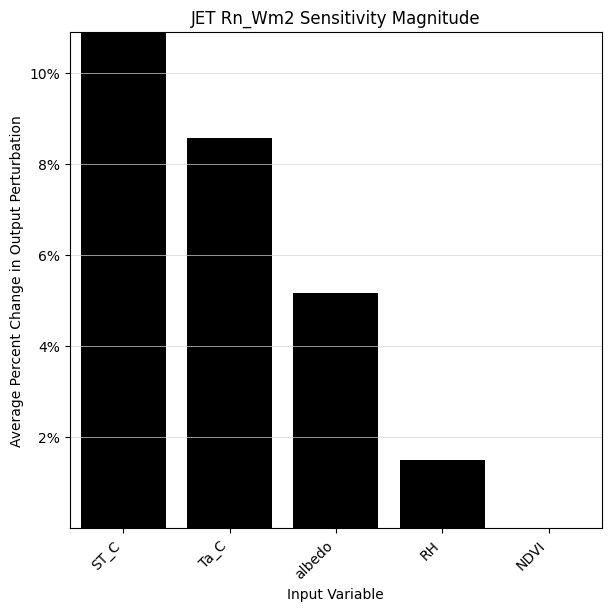

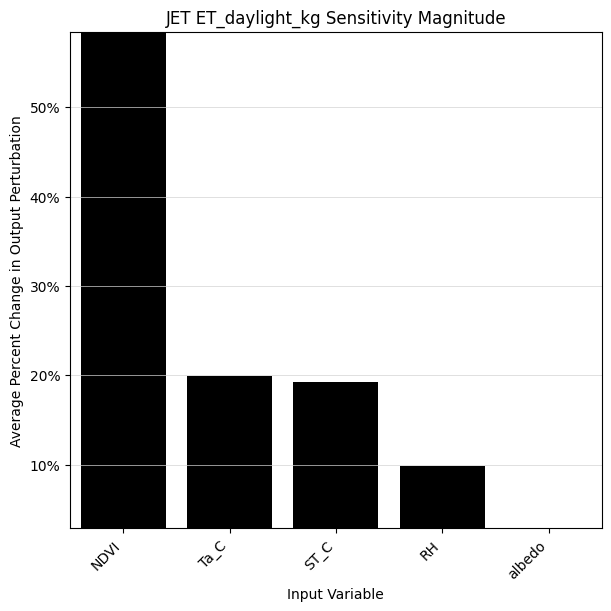

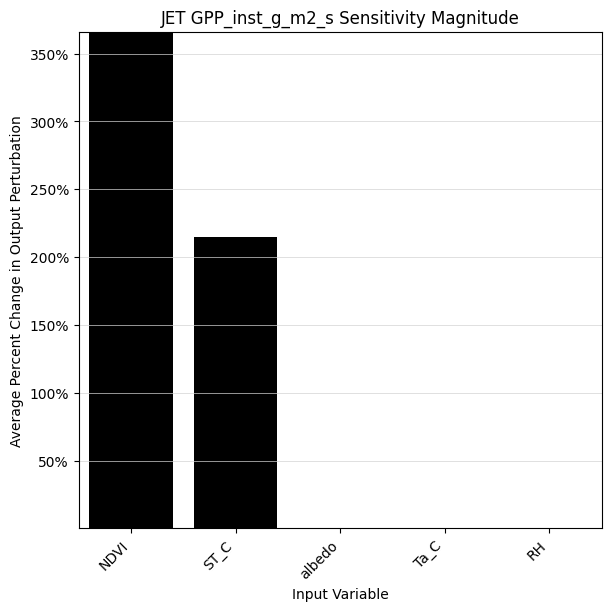

In [9]:
for output_variable in output_variables:
    sensitivity_magnitude_barchart(
        model_name=model_name,
        output_variable=output_variable,
        df=sensitivity_metrics_df
    )

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the BESS-JPL model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.